In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [2]:
!pip install -q transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


In [3]:
import transformers
import datasets
import sklearn

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Libraries installed successfully! ✅")

Transformers: 5.13.1
Datasets: 4.0.0
Libraries installed successfully! ✅


In [4]:
from google.colab import files

uploaded = files.upload()

Saving final_urdu_dataset.csv to final_urdu_dataset.csv


In [5]:
import pandas as pd

urdu_df = pd.read_csv(
    "final_urdu_dataset.csv",
    encoding="utf-8-sig"
)

print("Shape:", urdu_df.shape)
print(urdu_df.head())
print("\nColumns:", urdu_df.columns.tolist())
print("\nSentiment counts:")
print(urdu_df["sentiment"].value_counts())

Shape: (7095, 3)
                                             comment sentiment  \
0  اللہ آپکو سلامت رکھے جزائے خیر عطا فرمائے اور ...  positive   
1                                  اللہ سب سے بڑا ہے  positive   
2  سید محسن رضا نقوی پر یقین کرنے کو دل کرتا ھے ک...  positive   
3          نیازی خان ہیرو ثابت ہوا جیسے بڑوں گی مرضی  positive   
4                          آپ کی عظمت کو سلام شاہ جی  positive   

                                              tokens  
0  ['اللہ', 'آپکو', 'سلامت', 'رکھے', 'جزائے', 'خی...  
1                  ['اللہ', 'سب', 'سے', 'بڑا', 'ہے']  
2  ['سید', 'محسن', 'رضا', 'نقوی', 'پر', 'یقین', '...  
3  ['نیازی', 'خان', 'ہیرو', 'ثابت', 'ہوا', 'جیسے'...  
4    ['آپ', 'کی', 'عظمت', 'کو', 'سلام', 'شاہ', 'جی']  

Columns: ['comment', 'sentiment', 'tokens']

Sentiment counts:
sentiment
negative    4024
positive    3071
Name: count, dtype: int64


In [6]:
# ============================================
# STEP 4: PREPARE URDU DATA FOR BERT
# ============================================

urdu_df = urdu_df[["comment", "sentiment"]].copy()

# Remove missing values
urdu_df = urdu_df.dropna(subset=["comment", "sentiment"])

# Convert to string
urdu_df["comment"] = urdu_df["comment"].astype(str)
urdu_df["sentiment"] = urdu_df["sentiment"].astype(str).str.lower().str.strip()

# Encode labels
label_map = {
    "negative": 0,
    "positive": 1
}

urdu_df["label"] = urdu_df["sentiment"].map(label_map)

# Remove any unknown labels
urdu_df = urdu_df.dropna(subset=["label"])

urdu_df["label"] = urdu_df["label"].astype(int)

print("Dataset shape:", urdu_df.shape)
print("\nLabel distribution:")
print(urdu_df["label"].value_counts())

print("\nSample:")
print(urdu_df[["comment", "sentiment", "label"]].head())

Dataset shape: (7095, 3)

Label distribution:
label
0    4024
1    3071
Name: count, dtype: int64

Sample:
                                             comment sentiment  label
0  اللہ آپکو سلامت رکھے جزائے خیر عطا فرمائے اور ...  positive      1
1                                  اللہ سب سے بڑا ہے  positive      1
2  سید محسن رضا نقوی پر یقین کرنے کو دل کرتا ھے ک...  positive      1
3          نیازی خان ہیرو ثابت ہوا جیسے بڑوں گی مرضی  positive      1
4                          آپ کی عظمت کو سلام شاہ جی  positive      1


In [7]:
from sklearn.model_selection import train_test_split

# 80% train, 20% temporary
train_df, temp_df = train_test_split(
    urdu_df,
    test_size=0.20,
    random_state=42,
    stratify=urdu_df["label"]
)

# Split temporary into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (5676, 3)
Validation: (709, 3)
Testing: (710, 3)


In [8]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["comment", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["comment", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["comment", "label"]],
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['comment', 'label'],
    num_rows: 5676
})
Dataset({
    features: ['comment', 'label'],
    num_rows: 709
})
Dataset({
    features: ['comment', 'label'],
    num_rows: 710
})


In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("Tokenizer and BERT model loaded successfully! ✅")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizer and BERT model loaded successfully! ✅


In [10]:
def tokenize_function(examples):
    return tokenizer(
        examples["comment"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed! ✅")

Map:   0%|          | 0/5676 [00:00<?, ? examples/s]

Map:   0%|          | 0/709 [00:00<?, ? examples/s]

Map:   0%|          | 0/710 [00:00<?, ? examples/s]

Tokenization completed! ✅


In [11]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [12]:
training_args = TrainingArguments(
    output_dir="./urdu_bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

print("Starting Urdu BERT training... 🚀")

trainer.train()

Starting Urdu BERT training... 🚀


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.523828,0.857546,0.858738,0.857546,0.857852
2,0.217319,0.703658,0.854725,0.865567,0.854725,0.855371
3,0.112360,0.666316,0.868829,0.869521,0.868829,0.869034


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1065, training_loss=0.1643934599110778, metrics={'train_runtime': 641.8078, 'train_samples_per_second': 26.531, 'train_steps_per_second': 1.659, 'total_flos': 1120063762667520.0, 'train_loss': 0.1643934599110778, 'epoch': 3.0})

In [18]:
# ============================================
# STEP 12: URDU BERT TESTING
# ============================================

test_results = trainer.predict(test_tokenized)

print("Test Results:")
print(test_results.metrics)

Test Results:
{'test_loss': 0.7427437901496887, 'test_accuracy': 0.8605633802816901, 'test_precision': 0.8604847475658548, 'test_recall': 0.8605633802816901, 'test_f1': 0.8600182126727282, 'test_runtime': 5.4124, 'test_samples_per_second': 131.181, 'test_steps_per_second': 8.314}


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# Predictions
y_pred_urdu_bert = np.argmax(
    test_results.predictions,
    axis=1
)

# Actual labels
y_true_urdu_bert = test_results.label_ids

# Metrics
accuracy_bert = accuracy_score(
    y_true_urdu_bert,
    y_pred_urdu_bert
)

precision_bert = precision_score(
    y_true_urdu_bert,
    y_pred_urdu_bert,
    average="weighted"
)

recall_bert = recall_score(
    y_true_urdu_bert,
    y_pred_urdu_bert,
    average="weighted"
)

f1_bert = f1_score(
    y_true_urdu_bert,
    y_pred_urdu_bert,
    average="weighted"
)

print("====================================")
print("URDU BERT TEST RESULTS")
print("====================================")

print(f"Accuracy : {accuracy_bert:.4f}")
print(f"Precision: {precision_bert:.4f}")
print(f"Recall   : {recall_bert:.4f}")
print(f"F1 Score : {f1_bert:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true_urdu_bert,
        y_pred_urdu_bert,
        target_names=["negative", "positive"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_true_urdu_bert,
        y_pred_urdu_bert
    )
)

URDU BERT TEST RESULTS
Accuracy : 0.8606
Precision: 0.8605
Recall   : 0.8606
F1 Score : 0.8600

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.90      0.88       403
    positive       0.86      0.81      0.83       307

    accuracy                           0.86       710
   macro avg       0.86      0.85      0.86       710
weighted avg       0.86      0.86      0.86       710


Confusion Matrix:
[[362  41]
 [ 58 249]]


In [49]:
# Save Urdu BERT model and tokenizer

model.save_pretrained("urdu_bert")
tokenizer.save_pretrained("urdu_bert")

print("Urdu BERT model and tokenizer saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Urdu BERT model and tokenizer saved successfully!


In [50]:
import shutil

shutil.make_archive(
    "urdu_bert",
    "zip",
    "urdu_bert"
)

print("urdu_bert.zip created successfully!")

urdu_bert.zip created successfully!


In [51]:
import shutil
from google.colab import files

# Create ZIP files
shutil.make_archive("urdu_bert", "zip", "urdu_bert")
shutil.make_archive("roman_urdu_bert", "zip", "roman_urdu_bert")

print("Both BERT ZIP files created successfully!")

Both BERT ZIP files created successfully!


In [54]:
files.download("urdu_bert.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# ============================================
# STEP 13: SAVE URDU BERT MODEL
# ============================================

URDU_BERT_PATH = "/content/urdu_bert_model"

trainer.save_model(URDU_BERT_PATH)
tokenizer.save_pretrained(URDU_BERT_PATH)

print("Urdu BERT model saved successfully! ✅")
print("Location:", URDU_BERT_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Urdu BERT model saved successfully! ✅
Location: /content/urdu_bert_model


In [21]:
import os

print(os.listdir(URDU_BERT_PATH))

['tokenizer_config.json', 'model.safetensors', 'training_args.bin', 'tokenizer.json', 'config.json']


In [22]:
import shutil

shutil.make_archive(
    "/content/urdu_bert_model",
    "zip",
    "/content/urdu_bert_model"
)

print("ZIP created successfully! ✅")

ZIP created successfully! ✅


In [23]:
from google.colab import files

files.download(
    "/content/urdu_bert_model.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Roman_Urdu_SENTIMENT


In [24]:
from google.colab import files

uploaded = files.upload()

Saving final_roman_urdu_dataset.csv to final_roman_urdu_dataset.csv


In [25]:
import pandas as pd

roman_df = pd.read_csv(
    "final_roman_urdu_dataset.csv",
    encoding="utf-8-sig"
)

print("Shape:", roman_df.shape)
print(roman_df.head())

print("\nColumns:")
print(roman_df.columns.tolist())

print("\nSentiment counts:")
print(roman_df["sentiment"].value_counts())

Shape: (11299, 4)
                                             comment sentiment Unnamed: 2  \
0  sai kha ya her kisi kay bus ki bat nhi hai lak...  positive        NaN   
1                                      sahi but haan  positive        NaN   
2                                        kya but hai  positive        NaN   
3                                         wah je wah  positive        NaN   
4                               are wha kaya bat hai  positive        NaN   

                                              tokens  
0  ['sai', 'kha', 'ya', 'her', 'kisi', 'kay', 'bu...  
1                            ['sahi', 'but', 'haan']  
2                              ['kya', 'but', 'hai']  
3                               ['wah', 'je', 'wah']  
4               ['are', 'wha', 'kaya', 'bat', 'hai']  

Columns:
['comment', 'sentiment', 'Unnamed: 2', 'tokens']

Sentiment counts:
sentiment
positive    6013
negative    5286
Name: count, dtype: int64


In [26]:
roman_df = roman_df[["comment", "sentiment"]].copy()

# Remove missing values
roman_df = roman_df.dropna(
    subset=["comment", "sentiment"]
)

# Convert to string
roman_df["comment"] = roman_df["comment"].astype(str)

roman_df["sentiment"] = (
    roman_df["sentiment"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Encode labels
label_map = {
    "negative": 0,
    "positive": 1
}

roman_df["label"] = roman_df["sentiment"].map(label_map)

# Remove unknown labels
roman_df = roman_df.dropna(subset=["label"])

roman_df["label"] = roman_df["label"].astype(int)

print("Dataset shape:", roman_df.shape)

print("\nLabel distribution:")
print(roman_df["label"].value_counts())

print("\nSample:")
print(
    roman_df[
        ["comment", "sentiment", "label"]
    ].head()
)

Dataset shape: (11297, 3)

Label distribution:
label
1    6012
0    5285
Name: count, dtype: int64

Sample:
                                             comment sentiment  label
0  sai kha ya her kisi kay bus ki bat nhi hai lak...  positive      1
1                                      sahi but haan  positive      1
2                                        kya but hai  positive      1
3                                         wah je wah  positive      1
4                               are wha kaya bat hai  positive      1


In [27]:
from sklearn.model_selection import train_test_split

train_roman, temp_roman = train_test_split(
    roman_df,
    test_size=0.20,
    random_state=42,
    stratify=roman_df["label"]
)

val_roman, test_roman = train_test_split(
    temp_roman,
    test_size=0.50,
    random_state=42,
    stratify=temp_roman["label"]
)

print("Training:", train_roman.shape)
print("Validation:", val_roman.shape)
print("Testing:", test_roman.shape)

Training: (9037, 3)
Validation: (1130, 3)
Testing: (1130, 3)


In [28]:
from datasets import Dataset

train_roman_dataset = Dataset.from_pandas(
    train_roman[["comment", "label"]],
    preserve_index=False
)

val_roman_dataset = Dataset.from_pandas(
    val_roman[["comment", "label"]],
    preserve_index=False
)

test_roman_dataset = Dataset.from_pandas(
    test_roman[["comment", "label"]],
    preserve_index=False
)

print(train_roman_dataset)
print(val_roman_dataset)
print(test_roman_dataset)

Dataset({
    features: ['comment', 'label'],
    num_rows: 9037
})
Dataset({
    features: ['comment', 'label'],
    num_rows: 1130
})
Dataset({
    features: ['comment', 'label'],
    num_rows: 1130
})


In [29]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "bert-base-multilingual-cased"

roman_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

roman_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("Roman Urdu BERT loaded successfully! ✅")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Roman Urdu BERT loaded successfully! ✅


In [30]:
def tokenize_roman(examples):
    return roman_tokenizer(
        examples["comment"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_roman_tokenized = train_roman_dataset.map(
    tokenize_roman,
    batched=True
)

val_roman_tokenized = val_roman_dataset.map(
    tokenize_roman,
    batched=True
)

test_roman_tokenized = test_roman_dataset.map(
    tokenize_roman,
    batched=True
)

print("Roman Urdu tokenization completed! ✅")

Map:   0%|          | 0/9037 [00:00<?, ? examples/s]

Map:   0%|          | 0/1130 [00:00<?, ? examples/s]

Map:   0%|          | 0/1130 [00:00<?, ? examples/s]

Roman Urdu tokenization completed! ✅


In [31]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_roman_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [32]:
from transformers import TrainingArguments, Trainer

roman_training_args = TrainingArguments(
    output_dir="./roman_urdu_bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./roman_logs",
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [33]:
roman_trainer = Trainer(
    model=roman_model,
    args=roman_training_args,
    train_dataset=train_roman_tokenized,
    eval_dataset=val_roman_tokenized,
    compute_metrics=compute_roman_metrics
)

print("Starting Roman Urdu BERT training... 🚀")

roman_trainer.train()

Starting Roman Urdu BERT training... 🚀


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.610549,0.493663,0.745133,0.764451,0.745133,0.743364
2,0.469979,0.476776,0.777876,0.779674,0.777876,0.778112
3,0.364266,0.520054,0.773451,0.773695,0.773451,0.772689


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1695, training_loss=0.4640667985674203, metrics={'train_runtime': 937.1414, 'train_samples_per_second': 28.929, 'train_steps_per_second': 1.809, 'total_flos': 1783300955466240.0, 'train_loss': 0.4640667985674203, 'epoch': 3.0})

In [34]:
load_best_model_at_end=True
metric_for_best_model="f1"

In [35]:
# ============================================
# ROMAN URDU BERT TESTING
# ============================================

roman_test_results = roman_trainer.predict(
    test_roman_tokenized
)

print("Roman Urdu BERT Test Results:")
print(roman_test_results.metrics)

Roman Urdu BERT Test Results:
{'test_loss': 0.5001737475395203, 'test_accuracy': 0.7876106194690266, 'test_precision': 0.7896405356723315, 'test_recall': 0.7876106194690266, 'test_f1': 0.7878264048045759, 'test_runtime': 8.4905, 'test_samples_per_second': 133.09, 'test_steps_per_second': 8.362}


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# Predictions
y_pred_roman_bert = np.argmax(
    roman_test_results.predictions,
    axis=1
)

# Actual labels
y_true_roman_bert = roman_test_results.label_ids

# Metrics
accuracy_roman_bert = accuracy_score(
    y_true_roman_bert,
    y_pred_roman_bert
)

precision_roman_bert = precision_score(
    y_true_roman_bert,
    y_pred_roman_bert,
    average="weighted"
)

recall_roman_bert = recall_score(
    y_true_roman_bert,
    y_pred_roman_bert,
    average="weighted"
)

f1_roman_bert = f1_score(
    y_true_roman_bert,
    y_pred_roman_bert,
    average="weighted"
)

print("======================================")
print("ROMAN URDU BERT TEST RESULTS")
print("======================================")

print(f"Accuracy : {accuracy_roman_bert:.4f}")
print(f"Precision: {precision_roman_bert:.4f}")
print(f"Recall   : {recall_roman_bert:.4f}")
print(f"F1 Score : {f1_roman_bert:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_true_roman_bert,
        y_pred_roman_bert,
        target_names=["negative", "positive"]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_true_roman_bert,
        y_pred_roman_bert
    )
)

ROMAN URDU BERT TEST RESULTS
Accuracy : 0.7876
Precision: 0.7896
Recall   : 0.7876
F1 Score : 0.7878

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.81      0.78       529
    positive       0.82      0.77      0.79       601

    accuracy                           0.79      1130
   macro avg       0.79      0.79      0.79      1130
weighted avg       0.79      0.79      0.79      1130


Confusion Matrix:
[[427 102]
 [138 463]]


In [37]:
# ============================================
# SAVE ROMAN URDU BERT MODEL
# ============================================

ROMAN_BERT_PATH = "/content/roman_urdu_bert_model"

roman_trainer.save_model(ROMAN_BERT_PATH)
roman_tokenizer.save_pretrained(ROMAN_BERT_PATH)

print("Roman Urdu BERT model saved successfully! ✅")
print("Location:", ROMAN_BERT_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Roman Urdu BERT model saved successfully! ✅
Location: /content/roman_urdu_bert_model


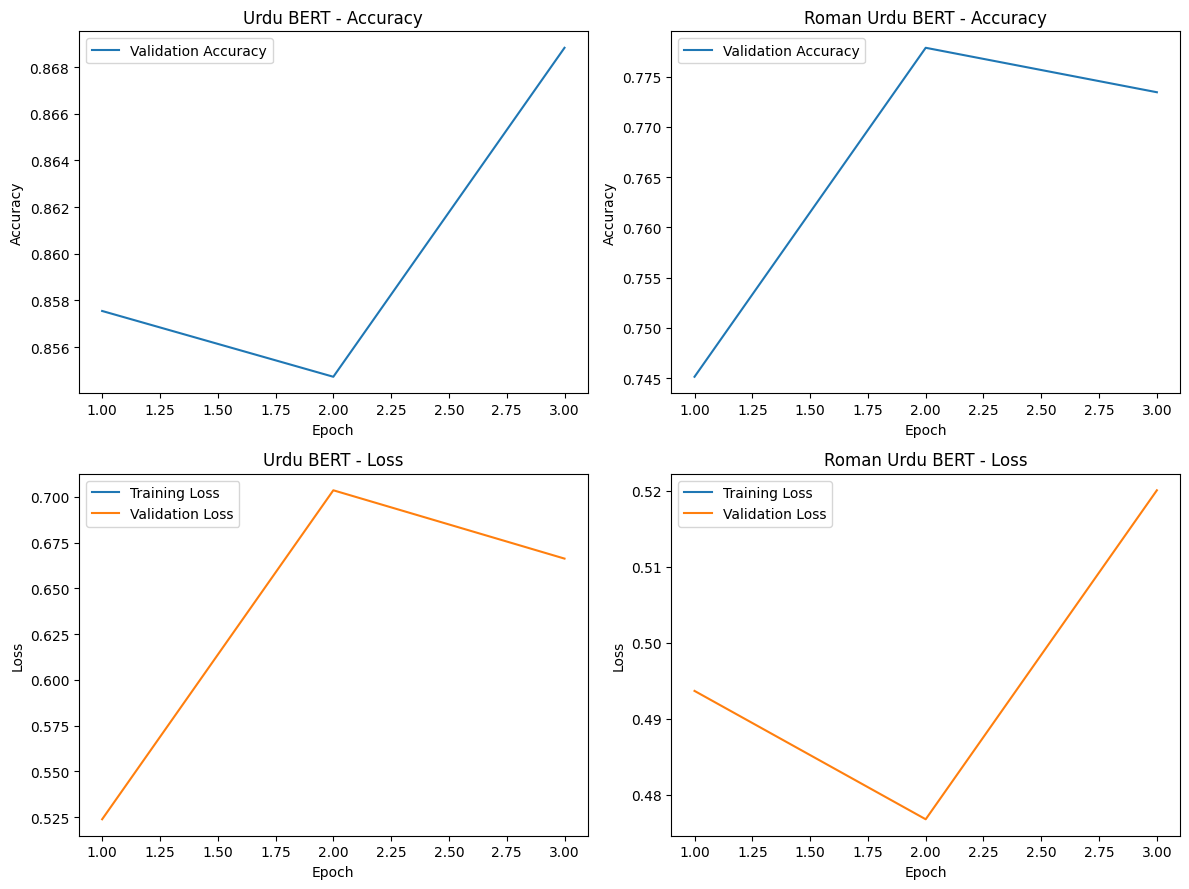

In [39]:
import matplotlib.pyplot as plt

# ============================================
# URDU + ROMAN URDU BERT
# TRAINING / VALIDATION ACCURACY & LOSS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Extract history from trainers
urdu_history = trainer.state.log_history
roman_history = roman_trainer.state.log_history

# Prepare lists for plotting
urdu_train_acc = []
urdu_val_acc = []
urdu_train_loss = []
urdu_val_loss = []

roman_train_acc = []
roman_val_acc = []
roman_train_loss = []
roman_val_loss = []

for entry in urdu_history:
    if 'loss' in entry: # Training loss
        urdu_train_loss.append(entry['loss'])
    if 'eval_loss' in entry: # Validation loss
        urdu_val_loss.append(entry['eval_loss'])
    if 'eval_accuracy' in entry: # Validation accuracy
        urdu_val_acc.append(entry['eval_accuracy'])
    if 'eval_f1' in entry: # Assuming the best model is chosen based on F1, so accuracy might not be logged for training steps.
        # We can't easily get per-epoch training accuracy directly from log_history in the same way as validation.
        # For simplicity, we'll plot validation accuracy vs epoch.
        pass


for entry in roman_history:
    if 'loss' in entry:
        roman_train_loss.append(entry['loss'])
    if 'eval_loss' in entry:
        roman_val_loss.append(entry['eval_loss'])
    if 'eval_accuracy' in entry:
        roman_val_acc.append(entry['eval_accuracy'])
    if 'eval_f1' in entry:
        pass

# The number of entries in `urdu_history` and `roman_history` might vary based on logging steps.
# We need to filter entries that correspond to epochs for plotting.

urdu_epochs_val_loss = [entry['eval_loss'] for entry in urdu_history if 'eval_loss' in entry]
urdu_epochs_val_acc = [entry['eval_accuracy'] for entry in urdu_history if 'eval_accuracy' in entry]

roman_epochs_val_loss = [entry['eval_loss'] for entry in roman_history if 'eval_loss' in entry]
roman_epochs_val_acc = [entry['eval_accuracy'] for entry in roman_history if 'eval_accuracy' in entry]

urdu_epochs_train_loss = [entry['loss'] for entry in urdu_history if 'loss' in entry and entry.get('step', 0) % (len(train_dataset) // trainer.args.per_device_train_batch_size) == 0]
roman_epochs_train_loss = [entry['loss'] for entry in roman_history if 'loss' in entry and entry.get('step', 0) % (len(train_roman_dataset) // roman_trainer.args.per_device_train_batch_size) == 0]

# -------------------------------
# Urdu Accuracy
# -------------------------------
axes[0, 0].plot(range(1, len(urdu_epochs_val_acc) + 1), urdu_epochs_val_acc, label="Validation Accuracy")
axes[0, 0].set_title("Urdu BERT - Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()

# -------------------------------
# Roman Urdu Accuracy
# -------------------------------
axes[0, 1].plot(range(1, len(roman_epochs_val_acc) + 1), roman_epochs_val_acc, label="Validation Accuracy")
axes[0, 1].set_title("Roman Urdu BERT - Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

# -------------------------------
# Urdu Loss
# -------------------------------
axes[1, 0].plot(range(1, len(urdu_epochs_train_loss) + 1), urdu_epochs_train_loss, label="Training Loss")
axes[1, 0].plot(range(1, len(urdu_epochs_val_loss) + 1), urdu_epochs_val_loss, label="Validation Loss")
axes[1, 0].set_title("Urdu BERT - Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

# -------------------------------
# Roman Urdu Loss
# -------------------------------
axes[1, 1].plot(range(1, len(roman_epochs_train_loss) + 1), roman_epochs_train_loss, label="Training Loss")
axes[1, 1].plot(range(1, len(roman_epochs_val_loss) + 1), roman_epochs_val_loss, label="Validation Loss")
axes[1, 1].set_title("Roman Urdu BERT - Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

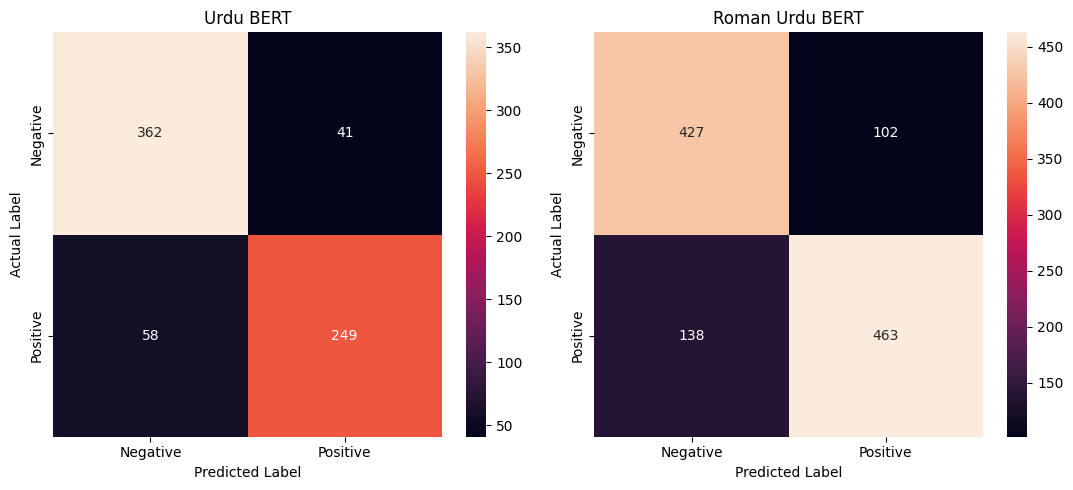

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# URDU + ROMAN URDU BERT CONFUSION MATRICES
# ==========================================

cm_urdu = [
    [362, 41],
    [58, 249]
]

cm_roman = [
    [427, 102],
    [138, 463]
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# -------------------------------
# Urdu BERT
# -------------------------------
sns.heatmap(
    cm_urdu,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[0]
)

axes[0].set_title("Urdu BERT")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# -------------------------------
# Roman Urdu BERT
# -------------------------------
sns.heatmap(
    cm_roman,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[1]
)

axes[1].set_title("Roman Urdu BERT")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [ ]:
import shutil

shutil.make_archive(
    "/content/roman_urdu_bert_model",
    "zip",
    "/content/roman_urdu_bert_model"
)

print("Roman Urdu BERT ZIP created successfully! ✅")

Roman Urdu BERT ZIP created successfully! ✅


In [ ]:
from google.colab import files

files.download(
    "/content/roman_urdu_bert_model.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# TEST URDU BERT WITH YOUR OWN COMMENTS
# ============================================

import torch

def predict_urdu(comment):
    inputs = tokenizer(
        comment,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    # Move inputs to same device as model
    device = next(roman_model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = trainer.model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)
    prediction = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][prediction].item()

    sentiment = "Positive 😊" if prediction == 1 else "Negative 😞"

    print("Comment:", comment)
    print("Prediction:", sentiment)
    print(f"Confidence: {confidence:.2%}")

    return sentiment, confidence

In [ ]:
device = next(model.parameters()).device

In [ ]:
predict_urdu("یہ فلم بہت اچھی ہے")

Comment: یہ فلم بہت اچھی ہے
Prediction: Positive 😊
Confidence: 99.36%


('Positive 😊', 0.9936019778251648)

In [ ]:
predict_urdu("یہ فلم بہت اچھی ہے")

predict_urdu("مجھے یہ چیز بالکل پسند نہیں آئی")

predict_urdu("واہ کیا خوبصورت کام کیا ہے")

predict_urdu("بہت خراب سروس ہے")

predict_urdu("اللہ آپ کو خوش رکھے")

predict_urdu("آپ نے بہت اچھا کام کیا")

Comment: یہ فلم بہت اچھی ہے
Prediction: Positive 😊
Confidence: 99.36%
Comment: مجھے یہ چیز بالکل پسند نہیں آئی
Prediction: Negative 😞
Confidence: 94.24%
Comment: واہ کیا خوبصورت کام کیا ہے
Prediction: Positive 😊
Confidence: 99.42%
Comment: بہت خراب سروس ہے
Prediction: Negative 😞
Confidence: 98.57%
Comment: اللہ آپ کو خوش رکھے
Prediction: Positive 😊
Confidence: 99.41%
Comment: آپ نے بہت اچھا کام کیا
Prediction: Positive 😊
Confidence: 99.38%


('Positive 😊', 0.9937877655029297)

In [ ]:
# ============================================
# TEST ROMAN URDU BERT WITH YOUR OWN COMMENTS
# ============================================

import torch

def predict_roman(comment):

    inputs = roman_tokenizer(
        comment,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    device = next(roman_trainer.model.parameters()).device

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = roman_trainer.model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )

    prediction = torch.argmax(
        probabilities,
        dim=-1
    ).item()

    confidence = probabilities[0][prediction].item()

    sentiment = (
        "Positive 😊"
        if prediction == 1
        else "Negative 😞"
    )

    print("Comment:", comment)
    print("Prediction:", sentiment)
    print(f"Confidence: {confidence:.2%}")

    return sentiment, confidence

In [ ]:
predict_roman("ye movie bohat achi hai")

Comment: ye movie bohat achi hai
Prediction: Positive 😊
Confidence: 98.61%


('Positive 😊', 0.9861119985580444)

In [ ]:
predict_roman("mujhe ye bilkul pasand nahi aya")

predict_roman("wah je wah bohat zabardast")

predict_roman("bohat bakwas service hai")

predict_roman("aap ne bohat acha kaam kia")

predict_roman("ye product bilkul kharab hai")

Comment: mujhe ye bilkul pasand nahi aya
Prediction: Negative 😞
Confidence: 74.93%
Comment: wah je wah bohat zabardast
Prediction: Positive 😊
Confidence: 99.10%
Comment: bohat bakwas service hai
Prediction: Negative 😞
Confidence: 70.12%
Comment: aap ne bohat acha kaam kia
Prediction: Positive 😊
Confidence: 99.17%
Comment: ye product bilkul kharab hai
Prediction: Negative 😞
Confidence: 81.87%


('Negative 😞', 0.8187164664268494)

In [44]:
print("Models:")
print([name for name in globals() if "model" in name.lower()])

print("\nTokenizers:")
print([name for name in globals() if "tokenizer" in name.lower()])

Models:
['AutoModelForSequenceClassification', 'MODEL_NAME', 'model', 'load_best_model_at_end', 'metric_for_best_model', 'roman_model']

Tokenizers:
['AutoTokenizer', 'tokenizer', 'roman_tokenizer']


In [45]:
# Save Roman Urdu BERT model
roman_model.save_pretrained("roman_urdu_bert")

# Save Roman Urdu tokenizer
roman_tokenizer.save_pretrained("roman_urdu_bert")

print("Roman Urdu BERT saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Roman Urdu BERT saved successfully!


In [46]:
import shutil

shutil.make_archive(
    "roman_urdu_bert",
    "zip",
    "roman_urdu_bert"
)

print("Roman Urdu BERT ZIP created successfully!")

Roman Urdu BERT ZIP created successfully!


In [47]:
from google.colab import files

files.download("roman_urdu_bert.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>